In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
from sklearn import linear_model
import seaborn as sns
import random 
import statistics 
import math 
import scipy as sc
from scipy.stats import chisquare
from collections import Counter
from scipy import stats
from collections import Counter

random.seed(42)

In [2]:
n_women = 1000
Q = np.array([
    [-0.0085,  0.005,  0.0025, 0,      0.001],
    [0,      -0.014,   0.005,  0.004,  0.005],
    [0,       0,      -0.008,  0.003,  0.005],
    [0,       0,       0,     -0.009,  0.009],
    [0,       0,       0,      0,      0]
])

In [3]:
#

def development_of_state(Q):
    state = 0 
    time = 0 
    series = [(state,time)] #simulated unit has its state connected to an entry time. 

    while state != 4: 
        transition_time = np.random.exponential(1/-Q[state][state])
        time += transition_time

        prop_list = [-q / Q[state][state] for q in Q[state][state+1:]]
        state = np.random.choice(np.arange(state+1, 5), p=prop_list)

        series.append((state, time)) #when a transistion happen. state and time are added to the units series. 
    
    return series




[[(0, 0), (2, 102.30967059136879), (4, 130.87149100977746)]]
[[0, 0, 0, 4]]


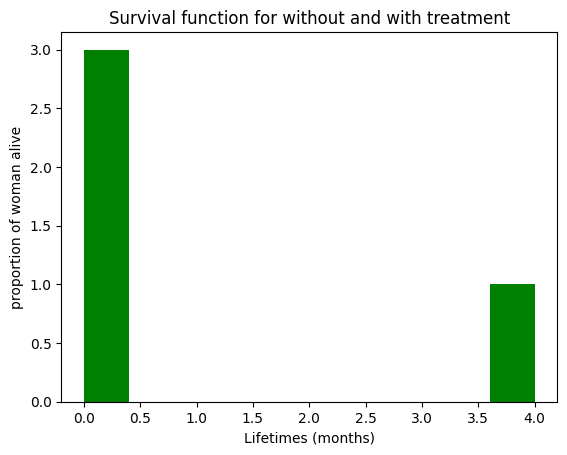

In [4]:

def state_vector(series):
    observed_state = [] #stores the observed states in order. should always end with 4 = death. 
    time = 0 
    while True:
        state = series[0][0] #starting in state (0,0)
        for (state_in_series, transistion_timestamp) in series:
            if transistion_timestamp <= time:
                state = state_in_series

        observed_state.append(state) 
        if state == 4:
            break
        time += 48 #months increment. correspond to 4 years. 
    return observed_state

series = [development_of_state(Q) for _ in range(1)]
ob = [state_vector(k) for k in series]

print(series)
print(ob)
plt.hist(ob, color="green", label='S(t) not treated')
plt.ylabel('proportion of woman alive')
plt.xlabel('Lifetimes (months)')

plt.title('Survival function for without and with treatment')
plt.show()

In [5]:
series = [development_of_state(Q) for _ in range(1000)] #1000 woman noted state vs time 
observed_development = [state_vector(k) for k in series ] 

observed_development[0]


[0, 0, 1, 1, 1, 1, 1, 1, 4]

In [6]:
def rejection_sample(start_state, end_state, Q):
    period = 48 #months 

    while True: #keep running until a consistent result 
        state = start_state
        t = 0 #time in gap starts in 0 
        transistions = [] #contains transistions
        time_spend_in_state = {} #contain pairs of state_i : time_spend_in_i 

        while t < period: #less than 48 months have gone by, keep running
            if state == 4:
                break #cause you're dead

            #the time spent in the state is the exp distributed random variable
            time_spend = np.random.exponential(1 / -Q[state][state])

            if t + time_spend >= period: #transistion happen after 48 month. 
                #the time spend in the state is the time spend in this loop + the time already recored for this state in the dictionary holding time spend.
                time_spend_in_state[state] = time_spend_in_state.get(state,0) + (period-t)
                break
            
            #consider the transition happen within the 48 month gap. then record transition and time spend
            time_spend_in_state[state] = time_spend_in_state.get(state,0) + time_spend
            t += time_spend #increment time 
            probabilities = [-q / Q[state][state] for q in Q[state][state+1:]]
            state= np.random.choice(np.arange(state+1, 5), p=probabilities)
            transistions.append(state)

        if state == end_state: 
            return transistions, time_spend_in_state


def loop_of_each_observed(observed_development, Q):
    all_transitions = []
    all_time_spend = {}

    for i in range(len(observed_development)-1): #all 48month gaps
        start = observed_development[i]
        end = observed_development[i+1]
        transition, time_spend = rejection_sample(start, end,Q)

        previous_state = start
        for j in transition:
            all_transitions.append((previous_state,j)) #the transition from previous to the next state
            previous_state = j #setting j as previous state for recording next transition

        for state, t in time_spend.items():
            all_time_spend[state] = all_time_spend.get(state,0) + t

    return all_transitions, all_time_spend

def N_S(data):
    N = {}
    S = {}

    for transitions, time_spend in data:
        for (i,j) in transitions:
            N[(i,j)] = N.get((i,j), 0) + 1
        for state, time in time_spend.items():
            S[state] = S.get(state, 0) + time

    return N, S



def update(N,S):
    Q_updated = np.zeros((5,5)) #5x5 matrix

    for (i,j), count in N.items():
        if i != j:
            Q_updated[i][j] = count / S[i]

    for i in range(5):
        Q_updated[i][i] = -sum(Q_updated[i][j] for j in range(5) if j != i) #adjust diagonal
    
    return Q_updated

In [7]:
# Q_current = Q
Q_current = np.array([
    [-0.05, 0.02, 0.02, 0.005, 0.005],
    [0.,   -0.05, 0.02, 0.02,  0.01 ],
    [0.,    0.,  -0.05, 0.02,  0.03 ],
    [0.,    0.,   0.,  -0.05,  0.05 ],
    [0.,    0.,   0.,   0.,    0.   ]
])

for i in range(50):
    result = [loop_of_each_observed(obs,Q_current) for obs in observed_development]
    N,S = N_S(result)
    Q_updated = update(N,S)

    difference = np.max(np.abs(Q_current-Q_updated))
    print(f"Iteration {i}, diff: {difference:.6f}")

    if difference < 1e-5: 
        break

    Q_current = Q_updated


print(Q_current)


Iteration 0, diff: 0.041337
Iteration 1, diff: 0.002451
Iteration 2, diff: 0.001289
Iteration 3, diff: 0.001330
Iteration 4, diff: 0.000354
Iteration 5, diff: 0.000567
Iteration 6, diff: 0.000361
Iteration 7, diff: 0.000613
Iteration 8, diff: 0.000371
Iteration 9, diff: 0.000400
Iteration 10, diff: 0.000477
Iteration 11, diff: 0.000460
Iteration 12, diff: 0.000267
Iteration 13, diff: 0.000313
Iteration 14, diff: 0.000488
Iteration 15, diff: 0.000222
Iteration 16, diff: 0.000300
Iteration 17, diff: 0.000266
Iteration 18, diff: 0.000360
Iteration 19, diff: 0.000535
Iteration 20, diff: 0.000387
Iteration 21, diff: 0.000334
Iteration 22, diff: 0.000181
Iteration 23, diff: 0.000173
Iteration 24, diff: 0.000301
Iteration 25, diff: 0.000462
Iteration 26, diff: 0.000445
Iteration 27, diff: 0.000269
Iteration 28, diff: 0.000176
Iteration 29, diff: 0.000255
Iteration 30, diff: 0.000400
Iteration 31, diff: 0.000210
Iteration 32, diff: 0.000297
Iteration 33, diff: 0.000211
Iteration 34, diff: 0.00